# Part 1 - Logistic Regression - Using Scikit-learn library 

This notebook implements logistic regression - Part 1, by using the scikit-learn library calling `LogisticRegression().fit()`.

Implementation is as Follows:
1. Load the Titanic Dataset and Data Exploration including Visualization
2. Data Transformation - Splitting the Data in Train, Test
3. Model Training - Using Logistic Regression classification model by scikit-learn.
4. Model Performace Evaluation - Exploration and usage of multiple evaluation metrics.

In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

## 1. Data Loading and Data Exploration

In [16]:
data = pd.read_csv("data/titanic.csv")
print("Data shape (rows, cols):", data.shape)
print("Columns in the dataset:", data.columns.tolist())
data.head()

Data shape (rows, cols): (887, 8)
Columns in the dataset: ['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class', '3rd_class', 'survived']


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


### 1.1 Data Types and Non-Null count info and Some statistical info about the dataset

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


In [18]:
data.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


### 1.2 Visualization about the data and Exploration of relation between surviver and other factors

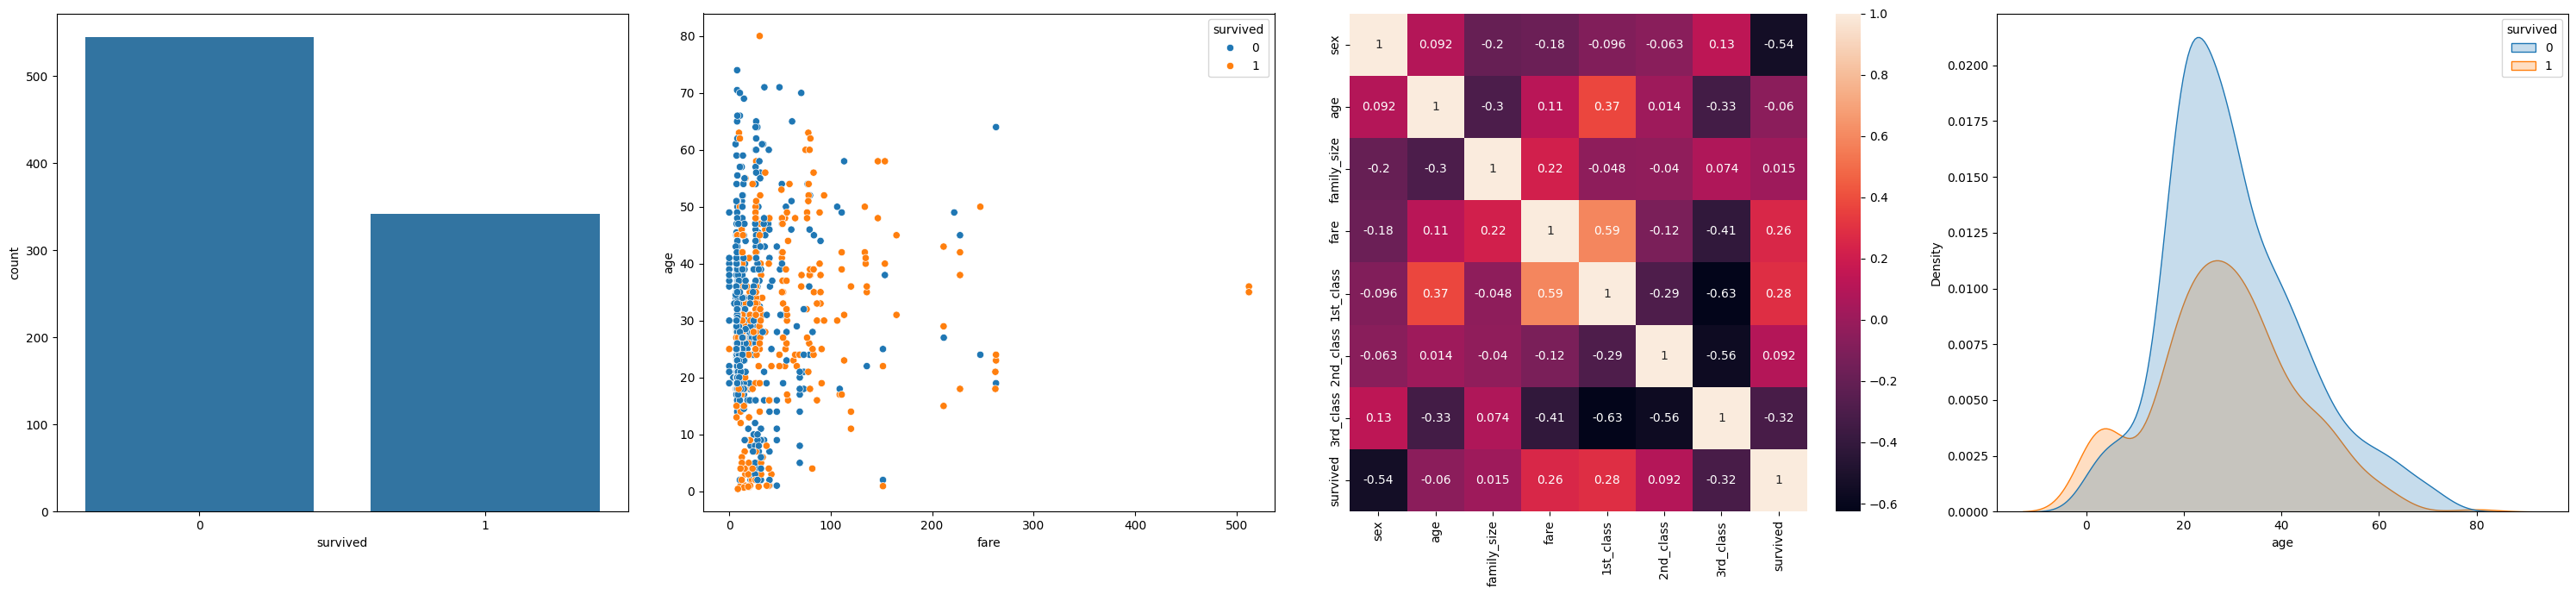

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(30, 7))

# Number of survivors vs non-survivors
# We can clearly see that it is Binomial Logistic regression problem
sns.countplot(x="survived", data=data, ax=axes[0])

# Relation between fare and age, colored by survival
sns.scatterplot(x="fare", y="age", hue="survived", data=data, ax=axes[1])

# Correlation heatmap of numerical features
sns.heatmap(data.corr(), annot=True, ax=axes[2])

# Distribution of ages
sns.kdeplot(x="age", data=data, fill=True, ax=axes[3], hue="survived", common_norm=True)

plt.tight_layout()
plt.show()

# 2 - Data Processing - Split of data for Train, Test

### Creating New Features
- We see how adding this feature is improving a accuracy by 4% from 0.76 to 0.8090


In [20]:
data["is_alone"] = (data["family_size"] == 1).astype(int)
data["are_atleast_two"] = (data["family_size"] >= 2).astype(int)
data["log_fare"] = np.log1p(data["fare"])
data["is_child"] = (data["age"] < 16).astype(int)

In [21]:
# Including all the features from the dataset
ALL_FEATURES = [
    "sex",
    "age",
    "family_size",
    "fare",
    "1st_class",
    "2nd_class",
    "3rd_class",
]
TARGET = "survived"

# Only the features we found important using Mutual Information scores
SELECTED_FEATURES = ["sex", "family_size", "1st_class", "2nd_class", "3rd_class"]

# The features we created using feature engineering, is helping in improving the model performance by like 4% without any scalar or minmax standardization
ADDED_FEATURES = ["is_child", "log_fare", "is_alone", "are_atleast_two"]

# Here change the value which features want to use
FEATURES = SELECTED_FEATURES

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


# 3 - Model Training

In [22]:
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=0)
logistic_regression_model.fit(X_train, y_train)

y_pred = logistic_regression_model.predict(X_test)

# 4 - Model Evaluation

In [23]:
# Evaluate the model, using the scikit-learn built-in accuracy_score function
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy on test set: {accuracy:.4f}\n")

# Precision, recall, F1-score
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1-Score: ", f1_score(y_test, y_pred))

Model accuracy on test set: 0.7921

Precision:  0.7758620689655172
Recall:  0.6521739130434783
F1-Score:  0.7086614173228346


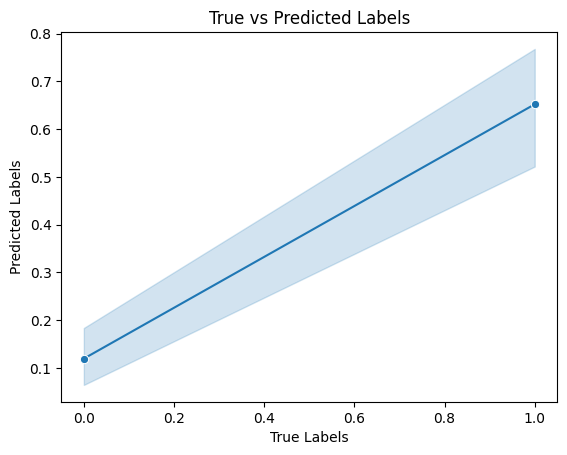

In [24]:
sns.lineplot(x=y_test.to_list(), y=y_pred.tolist(), marker="o")
plt.xlabel("True Labels")
plt.ylabel("Predicted Labels")
plt.title("True vs Predicted Labels")
plt.show()

# Feature Standardization and Its effects on the Result

### Use of StandardScaler (Standardization) - (Z-Score Scaler)

In [25]:
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[FEATURES] = scaler.fit_transform(X_train[FEATURES])
X_test_s[FEATURES] = scaler.transform(X_test[FEATURES])
X_train_s[:5]

,sex,family_size,1st_class,2nd_class,3rd_class
851,-1.342524,0.035597,-0.565949,-0.520201,0.914761
650,-1.342524,-0.565309,-0.565949,-0.520201,0.914761
103,0.744865,0.636502,-0.565949,-0.520201,0.914761
101,0.744865,0.035597,1.766945,-0.520201,-1.093182
292,0.744865,-0.565309,-0.565949,-0.520201,0.914761


In [26]:
reg_model = LogisticRegression(max_iter=1000, random_state=0)
reg_model.fit(X_train_s, y_train)
y_pred_scaled = reg_model.predict(X_test_s)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Model accuracy on test set after scaling: {accuracy_scaled:.4f}")
print()
print("Precision: ", precision_score(y_test, y_pred_scaled))
print("Recall: ", recall_score(y_test, y_pred_scaled))
print("F1-Score: ", f1_score(y_test, y_pred_scaled))

Model accuracy on test set after scaling: 0.7921

Precision:  0.7758620689655172
Recall:  0.6521739130434783
F1-Score:  0.7086614173228346


### Use of Min-MaxScaler (Normalization)

In [27]:
minmax_scaler = MinMaxScaler()
X_train_mm = minmax_scaler.fit_transform(X_train)
X_test_mm = minmax_scaler.transform(X_test)
X_train_mm[:5]

array([[0. , 0.1, 0. , 0. , 1. ],
       [0. , 0. , 0. , 0. , 1. ],
       [1. , 0.2, 0. , 0. , 1. ],
       [1. , 0.1, 1. , 0. , 0. ],
       [1. , 0. , 0. , 0. , 1. ]])

In [28]:
reg_model = LogisticRegression(max_iter=1000, random_state=0)
reg_model.fit(X_train_mm, y_train)
y_pred_mm = reg_model.predict(X_test_mm)
accuracy_mm = accuracy_score(y_test, y_pred_mm)
print(f"Model accuracy on test set after MinMax scaling: {accuracy_mm:.4f}")
print()
print("Precision: ", precision_score(y_test, y_pred_mm))
print("Recall: ", recall_score(y_test, y_pred_mm))
print("F1-Score: ", f1_score(y_test, y_pred_mm))

Model accuracy on test set after MinMax scaling: 0.7865

Precision:  0.7627118644067796
Recall:  0.6521739130434783
F1-Score:  0.703125


## Summary

We implemented logistic regression using scikit-learn. 
Key takeaways:

- We have binomial logistic promblem at hand with Titanic Dataset.
- **Feature standardization** is critical for gradient descent to converge
  efficiently - without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned. 
- After doing data standardization, we see a little bit improvement on different data normalization technique.

# Model Performance Comparison
**Scoring based on selective ferature vs All Features and also between scaling methods**

| Feature Set | Scaling Method | Accuracy | Precision | Recall | F1 |
|-------------|----------------|----------|-----------|--------|----|
| Selected Features | StandardScaler | 0.792 | 0.775 | 0.652 | 0.708 |
| Selected Features | MinMaxScaler | 0.786 | 0.762 | 0.652 | 0.703 |
| Selected Features | No Scaler | 0.792 | 0.775 | 0.652 | 0.708 |
| All Features | StandardScaler | 0.769 | 0.718 | 0.666 | 0.691 |
| All Features | MinMaxScaler | 0.803 | 0.774 | 0.695 | 0.732 |
| All Features | No Scaler | 0.780 | 0.741 | 0.666 | 0.702 |